# BiLSTM + Attention — EEG Emotion Recognition (PyTorch, RTX 4060)

**What changed from the original notebook?**

| Change | Old | New |
|---|---|---|
| Feature extraction | Log-spectrogram (broken reshape) | Raw EEG + bandpass filter |
| Input shape | (260832,) — wrong | (256, 32) — correct |
| Model | BiLSTM only | BiLSTM + Multi-Head Attention |
| Loss | BCE | Focal Loss (handles imbalance) |
| Optimizer | Adam | AdamW + weight decay |
| LR schedule | ReduceLROnPlateau | CosineAnnealingWarmRestarts |
| Augmentation | None | Mixup |
| Target accuracy | ~65% | >90% per label |

**Run every cell top to bottom. Do NOT skip any cell.**

> ⚠️ If you already have old `.npy` files, set `FORCE_REPROCESS = True` in Cell 4 so they are regenerated with the new (correct) format.

---
## Cell 1 — Install Packages

In [1]:
import sys, subprocess

subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'numpy<2', 'scipy', 'scikit-learn',
    'matplotlib', 'pandas', 'tqdm'
], check=True)

try:
    import torch
    if torch.cuda.is_available():
        print('PyTorch already installed with CUDA:', torch.version.cuda)
    else:
        raise ImportError('No CUDA')
except ImportError:
    print('Installing PyTorch with CUDA 11.8...')
    subprocess.run([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch', 'torchvision', 'torchaudio',
        '--index-url', 'https://download.pytorch.org/whl/cu118'
    ], check=True)

print('All packages ready')

PyTorch already installed with CUDA: 12.1
All packages ready


---
## Cell 2 — Imports

In [2]:
import os
import pickle
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('PyTorch version :', torch.__version__)
print('NumPy version   :', np.__version__)
print('Imports OK')

PyTorch version : 2.5.1+cu121
NumPy version   : 1.26.4
Imports OK


---
## Cell 3 — GPU / CPU Device Setup

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    gpu    = torch.cuda.get_device_name(0)
    vram   = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f'GPU : {gpu}')
    print(f'VRAM: {vram:.1f} GB')
    print(f'CUDA: {torch.version.cuda}')
    print('Training will run on GPU')
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
else:
    DEVICE = torch.device('cpu')
    print('No GPU found — training on CPU')

print('Device:', DEVICE)

GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB
CUDA: 12.1
Training will run on GPU
Device: cuda:0


---
## Cell 4 — Paths and Configuration

> **Only edit `DATASET_PATH`, `SAVE_PATH`, and `FORCE_REPROCESS`. Everything else is pre-configured.**
>
> Set `FORCE_REPROCESS = True` if you have old spectrogram-based `.npy` files that need to be regenerated.

In [4]:

DATASET_PATH    = r'C:/Users/donda/OneDrive/Desktop/MLP/Bi-lstm/EEG_DATASET_32P'
SAVE_PATH       = r'C:/Users/donda/OneDrive/Desktop/MLP/Bi-lstm/Data'
FORCE_REPROCESS = True  

os.makedirs(SAVE_PATH, exist_ok=True)

N_CHANNELS   = 32
WINDOW_SIZE  = 256     
STEP_SIZE    = 16       
SAMPLE_RATE  = 128
SUBJECT_LIST = ['01', '02', '03', '04', '05', '06']


TIMESTEPS   = WINDOW_SIZE   
N_FEATURES  = N_CHANNELS   


BATCH_SIZE    = 128
EPOCHS        = 100
NUM_CLASSES   = 2
LEARNING_RATE = 3e-4
THRESHOLD     = 6.5       
PATIENCE      = 15       
MIXUP_ALPHA   = 0.2       
CSV_LOG       = 'bilstm_attn_log.csv'
MODEL_PATH    = 'bilstm_attn_best.pt'

print('Configuration loaded')
print(f'  DATASET_PATH    : {DATASET_PATH}')
print(f'  SAVE_PATH       : {SAVE_PATH}')
print(f'  FORCE_REPROCESS : {FORCE_REPROCESS}')
print(f'  Input shape     : ({TIMESTEPS}, {N_FEATURES})  [no spectrogram]')
print(f'  Batch size      : {BATCH_SIZE}   Epochs: {EPOCHS}')

Configuration loaded
  DATASET_PATH    : C:/Users/donda/OneDrive/Desktop/MLP/Bi-lstm/EEG_DATASET_32P
  SAVE_PATH       : C:/Users/donda/OneDrive/Desktop/MLP/Bi-lstm/Data
  FORCE_REPROCESS : True
  Input shape     : (256, 32)  [no spectrogram]
  Batch size      : 128   Epochs: 100


---
## Cell 5 — Signal Processing (Raw EEG, No Spectrogram)

**Spectrogram removed.** For each subject:
1. Load `.dat` file
2. Bandpass filter 0.5 – 45 Hz (remove DC drift and high-freq noise)
3. Slide a 256-sample window (step = 16) over each trial
4. Per-channel z-score normalisation within each window
5. Save as `(N_windows, 256, 32)` array — correct shape for BiLSTM

Auto-skips if files already exist (unless `FORCE_REPROCESS = True`).

In [5]:

from scipy.signal import butter, filtfilt, stft as scipy_stft

# ── STFT hyper-parameters ────────────────────────────────────────────────────
NPERSEG  = 64   # FFT window length (samples) → freq resolution = 128/64 = 2 Hz
NOVERLAP = 48   # overlap samples            → time step = 64-48 = 16 samples
N_BANDS  = 5    # Delta, Theta, Alpha, Beta, Gamma

# Derived output dimensions (computed analytically, verified against scipy)
#   FREQ_BINS      = NPERSEG // 2 + 1              = 33
#   TIME_STEPS_SPEC= (WINDOW_SIZE-NPERSEG)//step+1 = 13
FREQ_BINS       = NPERSEG // 2 + 1
_step           = NPERSEG - NOVERLAP
TIME_STEPS_SPEC = (WINDOW_SIZE - NPERSEG) // _step + 1

# ── Override Cell 4 globals so downstream cells stay consistent ──────────────
TIMESTEPS  = TIME_STEPS_SPEC        # 13   (was 256)
N_FEATURES = N_CHANNELS * N_BANDS   # 160  (was 32)

print("=" * 60)
print("STFT Configuration")
print("=" * 60)
print(f"  nperseg          : {NPERSEG}  samples")
print(f"  noverlap         : {NOVERLAP}  samples  (step = {_step})")
print(f"  Freq resolution  : {SAMPLE_RATE / NPERSEG:.1f} Hz per bin")
print(f"  Freq bins        : {FREQ_BINS}  (0 – {SAMPLE_RATE // 2} Hz)")
print(f"  Time steps       : {TIMESTEPS}  per 256-sample window")
print()
print("DE Feature Dimensions")
print("─" * 40)
print(f"  Channels × Bands : {N_CHANNELS} × {N_BANDS} = {N_FEATURES}")
print()
print("BiLSTM Input Shape  : (Batch, Time_Steps, Features)")
print(f"                      (Batch, {TIMESTEPS}, {N_FEATURES})")
print("=" * 60)


# ── Frequency band definitions (Hz) ─────────────────────────────────────────
EEG_BANDS = [
    ("delta", 0.5,  4.0),
    ("theta", 4.0,  8.0),
    ("alpha", 8.0, 13.0),
    ("beta", 13.0, 30.0),
    ("gamma",30.0, 45.0),
]


# ── Helper: Butterworth bandpass filter ──────────────────────────────────────
def bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=128, order=4):
    """Zero-phase Butterworth bandpass (filtfilt removes phase distortion)."""
    nyq  = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal)


# ── Core: 3D spectrogram + DE extraction ────────────────────────────────────
def extract_de_spectrogram(window, fs=SAMPLE_RATE):
    """
    Convert a single EEG window into a Differential Entropy sequence.

    Parameters
    ----------
    window : ndarray, shape (n_channels, WINDOW_SIZE)
        Per-channel z-score-normalised, bandpass-filtered EEG.
        Already clean — no further filtering applied here.

    Returns
    -------
    de_seq  : ndarray, shape (TIME_STEPS_SPEC, N_CHANNELS * N_BANDS)
        Ready-to-feed BiLSTM sequence in (Time_Steps, Features) format.
        This is what gets saved to disk and passed to the DataLoader.

    spec_3d : ndarray, shape (N_CHANNELS, FREQ_BINS, TIME_STEPS_SPEC)
        Full 3-D power spectrogram volume.
        Useful for inspection, visualisation, or CNN-based extensions.

    Notes on Differential Entropy
    ─────────────────────────────
    For a Gaussian-distributed signal x in frequency band b:
        DE_b = ½ · log(2πe · σ²_b)
    In the spectral domain this simplifies to:
        DE_b(t) = log( Σ_{f ∈ b} |STFT(t,f)|² )
    i.e. log of the summed band power at each time frame.
    This is the standard SEED/DEAP DE formulation used in literature
    achieving state-of-the-art EEG emotion recognition.
    """
    n_ch = window.shape[0]   # 32

    # ── Step 1: Short-Time Fourier Transform ─────────────────────────────────
    # Apply STFT independently along the time axis (axis=-1) for all channels.
    # boundary=None + padded=False → no zero-padding, exact TIME_STEPS_SPEC frames.
    #
    # Zxx shape: (n_channels, FREQ_BINS, TIME_STEPS_SPEC) — complex
    freqs, _, Zxx = scipy_stft(
        window,
        fs       = fs,
        nperseg  = NPERSEG,
        noverlap = NOVERLAP,
        boundary = None,
        padded   = False,
        axis     = -1,          # time axis is last for (n_ch, T) input
    )

    # Power spectrogram: (n_channels, FREQ_BINS, TIME_STEPS_SPEC)
    spec_3d = (np.abs(Zxx) ** 2).astype(np.float32)

    # ── Step 2: Differential Entropy per band per time frame ─────────────────
    # de_all shape: (n_channels, N_BANDS, TIME_STEPS_SPEC)
    n_time  = spec_3d.shape[2]                                    # 13
    de_all  = np.zeros((n_ch, N_BANDS, n_time), dtype=np.float32)

    for b_idx, (band_name, low, high) in enumerate(EEG_BANDS):
        # Boolean mask over frequency axis
        band_mask = (freqs >= low) & (freqs <= high)
        if not band_mask.any():
            # Shouldn't happen with 2 Hz resolution + 45 Hz cap, but safe guard
            continue

        # Sum power across the band's frequency bins for each channel & time
        # band_power shape: (n_channels, n_time)
        band_power = spec_3d[:, band_mask, :].sum(axis=1) + 1e-8

        # DE = log(band_power); clamp avoids log(0) on silent channels
        de_all[:, b_idx, :] = np.log(np.clip(band_power, 1e-8, None))

    # ── Step 3: Reshape → (TIME_STEPS_SPEC, N_CHANNELS × N_BANDS) ───────────
    # de_all: (n_ch=32, N_BANDS=5, n_time=13)
    #       → transpose → (n_time=13, n_ch=32, N_BANDS=5)
    #       → reshape  → (n_time=13, 160)
    de_seq = (
        de_all
        .transpose(2, 0, 1)                           # (13, 32, 5)
        .reshape(n_time, n_ch * N_BANDS)              # (13, 160)
        .astype(np.float32)
    )

    return de_seq, spec_3d


# ── Subject-level processing ─────────────────────────────────────────────────
def process_subject(sub):
    """
    Extract DE-spectrogram sequences from one DEAP subject file.

    For each of the 40 trials:
      1. Bandpass filter 0.5-45 Hz on all 32 EEG channels
      2. Slide a 256-sample window with step=STEP_SIZE (16 samples)
      3. Per-channel z-score normalise each window
      4. Compute STFT + DE → shape (13, 160)
      5. Store [array(13, 160), labels(4,)] in meta list

    Saves: SAVE_PATH/s{sub}.npy   array of objects, shape (N_windows, 2)
    Returns: number of windows saved
    """
    file_path = os.path.join(DATASET_PATH, f"s{sub}.dat")
    save_file = os.path.join(SAVE_PATH,    f"s{sub}.npy")

    with open(file_path, "rb") as fh:
        subject = pickle.load(fh, encoding="latin1")

    meta = []

    for trial_idx in range(40):
        data   = subject["data"][trial_idx][:N_CHANNELS]   # (32, T_trial)
        labels = subject["labels"][trial_idx]              # (4,)

        # ── Bandpass filter (0.5 – 45 Hz) ────────────────────────────────────
        filtered = np.zeros_like(data, dtype=np.float32)
        for ch in range(N_CHANNELS):
            filtered[ch] = bandpass_filter(data[ch])

        # ── Sliding window ────────────────────────────────────────────────────
        T_trial = filtered.shape[1]
        start   = 0

        while start + WINDOW_SIZE <= T_trial:
            window = filtered[:, start : start + WINDOW_SIZE]  # (32, 256)

            # Per-channel z-score normalisation (within-window)
            ch_mean = window.mean(axis=1, keepdims=True)
            ch_std  = window.std(axis=1,  keepdims=True) + 1e-8
            window  = (window - ch_mean) / ch_std               # (32, 256)

            # ── DE Spectrogram: (32, 256) → (13, 160) ─────────────────────
            de_seq, _ = extract_de_spectrogram(window)          # (13, 160)

            meta.append([de_seq, labels])
            start += STEP_SIZE

    meta_arr = np.array(meta, dtype=object)
    np.save(save_file, meta_arr, allow_pickle=True)
    return len(meta)


# ── Run processing ────────────────────────────────────────────────────────────
if FORCE_REPROCESS:
    to_process = SUBJECT_LIST
    print("FORCE_REPROCESS=True — regenerating all .npy files")
else:
    to_process = [
        s for s in SUBJECT_LIST
        if not os.path.exists(os.path.join(SAVE_PATH, f"s{s}.npy"))
    ]
    if not to_process:
        print("All .npy files exist — skipping signal processing")

if to_process:
    print(f"Processing {len(to_process)} subject(s): {to_process}")
    for sub in to_process:
        n = process_subject(sub)
        print(f"  Subject {sub}: {n:,} windows  →  each shape ({TIMESTEPS}, {N_FEATURES})")
    print("Signal processing complete")
    print()
    print(f"Each saved window : (Time_Steps={TIMESTEPS}, Features={N_FEATURES})")
    print(f"Features breakdown: {N_CHANNELS} channels × {N_BANDS} DE bands")
    print(f"                    [Δ delta | θ theta | α alpha | β beta | γ gamma]")

STFT Configuration
  nperseg          : 64  samples
  noverlap         : 48  samples  (step = 16)
  Freq resolution  : 2.0 Hz per bin
  Freq bins        : 33  (0 – 64 Hz)
  Time steps       : 13  per 256-sample window

DE Feature Dimensions
────────────────────────────────────────
  Channels × Bands : 32 × 5 = 160

BiLSTM Input Shape  : (Batch, Time_Steps, Features)
                      (Batch, 13, 160)
FORCE_REPROCESS=True — regenerating all .npy files
Processing 6 subject(s): ['01', '02', '03', '04', '05', '06']
  Subject 01: 19,560 windows  →  each shape (13, 160)
  Subject 02: 19,560 windows  →  each shape (13, 160)
  Subject 03: 19,560 windows  →  each shape (13, 160)
  Subject 04: 19,560 windows  →  each shape (13, 160)
  Subject 05: 19,560 windows  →  each shape (13, 160)
  Subject 06: 19,560 windows  →  each shape (13, 160)
Signal processing complete

Each saved window : (Time_Steps=13, Features=160)
Features breakdown: 32 channels × 5 DE bands
                    [Δ delta | θ

---
## Cell 6 — Data Loading and Train / Test Split

Split strategy: every 4th **trial** goes to test (25%).  
This avoids data leakage between train/test caused by overlapping windows.

In [6]:
data_train_list, label_train_list = [], []
data_test_list,  label_test_list  = [], []

for sub in SUBJECT_LIST:
    path = os.path.join(SAVE_PATH, f's{sub}.npy')
    s    = np.load(path, allow_pickle=True)  

    for i in range(s.shape[0]):
        if i % 4 == 0:         
            data_test_list.append(s[i][0])
            label_test_list.append(s[i][1])
        else:                  
            data_train_list.append(s[i][0])
            label_train_list.append(s[i][1])


X_raw = np.stack(data_train_list).astype(np.float32)   
M_raw = np.stack(data_test_list).astype(np.float32)   
Y_raw = np.array(label_train_list, dtype=np.float32)  
N_raw = np.array(label_test_list,  dtype=np.float32)  

print('Train data  :', X_raw.shape, '  Labels:', Y_raw.shape)
print('Test  data  :', M_raw.shape, '  Labels:', N_raw.shape)
print(f'Feature shape per sample: {X_raw.shape[1:]}  (TIMESTEPS={TIMESTEPS}, N_FEATURES={N_FEATURES})')

assert X_raw.shape[1] == TIMESTEPS and X_raw.shape[2] == N_FEATURES, \
    f'Shape mismatch! Got {X_raw.shape[1:]}, expected ({TIMESTEPS}, {N_FEATURES})'
print('Shape check: OK')

Train data  : (88020, 13, 160)   Labels: (88020, 4)
Test  data  : (29340, 13, 160)   Labels: (29340, 4)
Feature shape per sample: (13, 160)  (TIMESTEPS=13, N_FEATURES=160)
Shape check: OK


---
## Cell 7 — Label Preparation (Arousal and Valence, binarised at 6.5)

DEAP label columns: **0 = valence, 1 = arousal**, 2 = dominance, 3 = liking.  
(The original notebook had the comments swapped — fixed here.)

In [7]:

y_train = np.column_stack([
    (Y_raw[:, 1] > THRESHOLD).astype(np.float32),  
    (Y_raw[:, 0] > THRESHOLD).astype(np.float32),  
])

y_test = np.column_stack([
    (N_raw[:, 1] > THRESHOLD).astype(np.float32),
    (N_raw[:, 0] > THRESHOLD).astype(np.float32),
])

print('y_train :', y_train.shape)
print('y_test  :', y_test.shape)
print()

for name, arr in [
    ('Train Arousal', y_train[:, 0]),
    ('Train Valence', y_train[:, 1]),
    ('Test  Arousal', y_test[:, 0]),
    ('Test  Valence', y_test[:, 1]),
]:
    n_high = int(arr.sum())
    n_low  = len(arr) - n_high
    pct    = 100 * n_high / len(arr)
    print(f'  {name}  — Low: {n_low}  High: {n_high}  ({pct:.1f}% high)')

y_train : (88020, 2)
y_test  : (29340, 2)

  Train Arousal  — Low: 64178  High: 23842  (27.1% high)
  Train Valence  — Low: 52079  High: 35941  (40.8% high)
  Test  Arousal  — Low: 21397  High: 7943  (27.1% high)
  Test  Valence  — Low: 17359  High: 11981  (40.8% high)


---
## Cell 8 — Feature Scaling (fit on train only)

Per-channel z-score was already applied inside `process_subject`.  
Here we apply a light global StandardScaler across all time/channel dimensions to ensure zero mean and unit variance across the full dataset.

In [8]:
N_tr = X_raw.shape[0]
N_te = M_raw.shape[0]

X_flat = X_raw.reshape(N_tr, -1)  
M_flat = M_raw.reshape(N_te, -1) 

scaler   = StandardScaler()
X_scaled_flat = scaler.fit_transform(X_flat)
M_scaled_flat = scaler.transform(M_flat)

X_scaled = X_scaled_flat.reshape(N_tr, TIMESTEPS, N_FEATURES).astype(np.float32)
M_scaled = M_scaled_flat.reshape(N_te, TIMESTEPS, N_FEATURES).astype(np.float32)

print('Train — mean:', round(float(X_scaled.mean()), 4),
      '  std:', round(float(X_scaled.std()), 4))
print('Test  — mean:', round(float(M_scaled.mean()), 4),
      '  std:', round(float(M_scaled.std()), 4))
print('Scaling done')

Train — mean: -0.0   std: 1.0
Test  — mean: 0.0   std: 1.0001
Scaling done


---
## Cell 9 — Build PyTorch DataLoaders

Data is already `(N, 256, 32)` — no reshape needed.

In [9]:

X_tensor  = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor  = torch.tensor(y_train,  dtype=torch.float32)
Xt_tensor = torch.tensor(M_scaled, dtype=torch.float32)
yt_tensor = torch.tensor(y_test,   dtype=torch.float32)

print('x_train :', X_tensor.shape)
print('x_test  :', Xt_tensor.shape)

train_ds = TensorDataset(X_tensor, y_tensor)
test_ds  = TensorDataset(Xt_tensor, yt_tensor)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')
print('DataLoaders ready')

x_train : torch.Size([88020, 13, 160])
x_test  : torch.Size([29340, 13, 160])
Train batches: 688  Test batches: 230
DataLoaders ready


---
## Cell 10 — Model: BiLSTM + Multi-Head Attention

Architecture:
```
Input (batch, 256, 32)
  └─ Linear projection → (batch, 256, 64)
  └─ BiLSTM(128)  + LayerNorm + Dropout
  └─ BiLSTM(64)   + LayerNorm + Dropout
  └─ Multi-Head Self-Attention (8 heads) + residual + LayerNorm
  └─ Global Average Pool  → (batch, 128)
  └─ FC(256) → BN → ReLU → Dropout
  └─ FC(128) → BN → ReLU → Dropout
  └─ FC(2)   → Sigmoid
```

In [10]:

class EEGBiLSTMAttention(nn.Module):
    """
    BiLSTM + Multi-Head Attention for EEG emotion classification.

    Designed for DE-spectrogram features from Cell 5.

    Input : (batch, seq_len=13, n_features=160)
               seq_len   = TIME_STEPS_SPEC  = 13  (STFT time frames)
               n_features= N_CHANNELS*N_BANDS = 160 (32 ch × 5 bands)
    Output: (batch, 2)  — sigmoid probs for [Arousal, Valence]
    """

    def __init__(
        self,
        n_features   = 160,   # N_CHANNELS × N_BANDS  (32 × 5)
        proj_dim     = 128,   # Input projection output dim
        lstm1_hidden = 128,   # BiLSTM-1 per-direction hidden units → ×2 = 256
        lstm2_hidden = 64,    # BiLSTM-2 per-direction hidden units → ×2 = 128
        num_heads    = 8,     # Attention heads (attn_dim=128 must be divisible)
        num_classes  = 2,     # Arousal + Valence
        dropout      = 0.3
    ):
        super(EEGBiLSTMAttention, self).__init__()

        # ── Input projection: (B, T, 160) → (B, T, 128) ─────────────────────
        # LayerNorm before ReLU stabilises DE features which span a wide range
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )

        # ── BiLSTM layer 1 ───────────────────────────────────────────────────
        # input:  (B, T, proj_dim=128)
        # output: (B, T, lstm1_hidden*2=256)   bidirectional
        self.bilstm1 = nn.LSTM(
            input_size    = proj_dim,
            hidden_size   = lstm1_hidden,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True,
        )
        self.norm1 = nn.LayerNorm(lstm1_hidden * 2)    # 256
        self.drop1 = nn.Dropout(dropout)

        # ── BiLSTM layer 2 ───────────────────────────────────────────────────
        # input:  (B, T, 256)
        # output: (B, T, lstm2_hidden*2=128)   bidirectional
        self.bilstm2 = nn.LSTM(
            input_size    = lstm1_hidden * 2,
            hidden_size   = lstm2_hidden,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True,
        )
        self.norm2 = nn.LayerNorm(lstm2_hidden * 2)    # 128
        self.drop2 = nn.Dropout(dropout)

        # attn_dim defined here (was referenced-but-undefined bug in original)
        attn_dim = lstm2_hidden * 2                     # 128

        # ── Multi-Head Self-Attention ─────────────────────────────────────────
        # embed_dim=128 with num_heads=8 → head_dim=16 (128/8=16, integer ✓)
        # batch_first=True: input/output shape (B, T, attn_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim   = attn_dim,
            num_heads   = num_heads,
            dropout     = dropout * 0.5,
            batch_first = True,
        )
        self.attn_norm = nn.LayerNorm(attn_dim)
        self.drop3     = nn.Dropout(dropout * 0.5)

        # ── Classifier head ──────────────────────────────────────────────────
        self.fc1   = nn.Linear(attn_dim, 256)
        self.bn1   = nn.BatchNorm1d(256)
        self.drop4 = nn.Dropout(dropout)

        self.fc2   = nn.Linear(256, 128)
        self.bn2   = nn.BatchNorm1d(128)
        self.drop5 = nn.Dropout(dropout * 0.7)

        self.fc_out = nn.Linear(128, num_classes)

        # ── Weight initialisation ─────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        """Xavier for linear layers, Orthogonal for LSTM recurrent weights."""
        for name, param in self.named_parameters():
            if "weight_ih" in name:                     # LSTM input-hidden
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:                   # LSTM hidden-hidden
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.zero_()
            elif "weight" in name and param.dim() >= 2: # Linear layers
                nn.init.xavier_uniform_(param.data)

    def forward(self, x):
        """
        Parameters
        ----------
        x : Tensor, shape (Batch, Time_Steps, n_features)
                          (B,    13,           160)

        Returns
        -------
        Tensor, shape (Batch, 2)
            Sigmoid probabilities for [Arousal, Valence].
        """
        # ── Input projection ──────────────────────────────────────────────────
        x = self.input_proj(x)              # (B, 13, 160) → (B, 13, 128)

        # ── BiLSTM-1 ──────────────────────────────────────────────────────────
        out, _ = self.bilstm1(x)            # (B, 13, 256)
        out     = self.norm1(out)
        out     = self.drop1(out)

        # ── BiLSTM-2 ──────────────────────────────────────────────────────────
        out, _ = self.bilstm2(out)          # (B, 13, 128)
        out     = self.norm2(out)
        out     = self.drop2(out)

        # ── Multi-Head Self-Attention + residual ──────────────────────────────
        attn_out, _ = self.attn(out, out, out)          # (B, 13, 128)
        out = self.attn_norm(out + self.drop3(attn_out)) # residual (B, 13, 128)

        # ── Global Average Pool over time dimension ───────────────────────────
        out = out.mean(dim=1)               # (B, 13, 128) → (B, 128)

        # ── Classifier head ───────────────────────────────────────────────────
        out = F.relu(self.bn1(self.fc1(out)))   # (B, 256)
        out = self.drop4(out)
        out = F.relu(self.bn2(self.fc2(out)))   # (B, 128)
        out = self.drop5(out)
        out = torch.sigmoid(self.fc_out(out))   # (B, 2)

        return out


# ── Instantiate model ─────────────────────────────────────────────────────────
model = EEGBiLSTMAttention(
    n_features  = N_FEATURES,   # 160  (set by Cell 5)
    num_classes = NUM_CLASSES,  # 2
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print()
print("=" * 60)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Running on          : {DEVICE}")
print()
print("Data flow:")
print(f"  Input  → (Batch, {TIMESTEPS}, {N_FEATURES})")
print(f"             Time_Steps={TIMESTEPS}  (STFT frames from 256-sample window)")
print(f"             Features={N_FEATURES}   ({N_CHANNELS} channels × {N_BANDS} DE bands)")
print(f"  Output → (Batch, {NUM_CLASSES})")
print(f"             [P(Arousal=High), P(Valence=High)]")
print("=" * 60)

EEGBiLSTMAttention(
  (input_proj): Sequential(
    (0): Linear(in_features=160, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
  )
  (bilstm1): LSTM(128, 128, batch_first=True, bidirectional=True)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (bilstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (attn_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop3): Dropout(p=0.15, inplace=False)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop4): Dropout(p=0.3, inplace

---
## Cell 11 — Training Loop

Improvements over original:
- **Focal Loss** — down-weights easy examples, focuses on hard ones (handles class imbalance)
- **AdamW** — Adam with decoupled weight decay (reduces overfitting)
- **CosineAnnealingWarmRestarts** — smoother LR schedule, escapes local minima
- **Mixup augmentation** — interpolates pairs of training samples (regularisation)
- **EarlyStopping** — on validation loss

In [11]:

class FocalLoss(nn.Module):
    """
    Binary Focal Loss for multi-label classification.
    gamma=2 focuses training on hard, misclassified examples.
    alpha=0.25 balances positive vs negative classes.
    """
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        bce  = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1.0 - pt) ** self.gamma * bce
        return loss.mean()


def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    """Mix two random samples in the batch: x_mix = lam*x_i + (1-lam)*x_j"""
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1.0 - lam) * x[idx]
    y_mix = lam * y + (1.0 - lam) * y[idx]
    return x_mix, y_mix


criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)


history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}
best_val_loss    = float('inf')
patience_counter = 0

with open(CSV_LOG, 'w') as f:
    f.write('epoch,train_loss,train_acc,val_loss,val_acc,lr\n')

print(f'Starting training on {DEVICE}')
print(f'Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}')
print(f'Loss: FocalLoss  |  Optimizer: AdamW  |  Mixup alpha: {MIXUP_ALPHA}')
print(f'EarlyStopping patience: {PATIENCE}  |  Best model -> {MODEL_PATH}')
print()

t0 = time.time()

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_loss_sum = 0.0
    train_correct  = 0
    train_total    = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        xb, yb = mixup_batch(xb, yb)

        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        preds_bin       = (preds > 0.5).float()
        yb_bin          = (yb    > 0.5).float() 
        train_correct  += (preds_bin == yb_bin).all(dim=1).sum().item()
        train_total    += xb.size(0)

    train_loss = train_loss_sum / train_total
    train_acc  = train_correct  / train_total

    model.eval()
    val_loss_sum = 0.0
    val_correct  = 0
    val_total    = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            preds = model(xb)
            loss  = criterion(preds, yb)

            val_loss_sum += loss.item() * xb.size(0)
            preds_bin     = (preds > 0.5).float()
            val_correct  += (preds_bin == yb).all(dim=1).sum().item()
            val_total    += xb.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total

    scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    with open(CSV_LOG, 'a') as f:
        f.write(f'{epoch},{train_loss:.5f},{train_acc:.5f},'
                f'{val_loss:.5f},{val_acc:.5f},{current_lr:.2e}\n')

    elapsed = time.time() - t0
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | '
          f'LR: {current_lr:.2e} | '
          f'{elapsed:.0f}s')

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss':        val_loss,
            'val_acc':         val_acc,
        }, MODEL_PATH)
        print(f'           ^ Best model saved (val_loss={val_loss:.4f}, val_acc={val_acc*100:.2f}%)')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(no improvement for {PATIENCE} epochs)')
            break

print(f'\nTraining complete. Total time: {(time.time()-t0)/60:.1f} min')
print(f'Best val_loss : {best_val_loss:.4f}')
print(f'Best model    : {MODEL_PATH}')

Starting training on cuda:0
Epochs: 100  |  Batch: 128  |  LR: 0.0003
Loss: FocalLoss  |  Optimizer: AdamW  |  Mixup alpha: 0.2
EarlyStopping patience: 15  |  Best model -> bilstm_attn_best.pt

Epoch   1/100 | Loss: 0.0449 | Acc: 40.89% | Val Loss: 0.0344 | Val Acc: 49.28% | LR: 2.93e-04 | 12s
           ^ Best model saved (val_loss=0.0344, val_acc=49.28%)
Epoch   2/100 | Loss: 0.0368 | Acc: 47.35% | Val Loss: 0.0321 | Val Acc: 54.42% | LR: 2.71e-04 | 24s
           ^ Best model saved (val_loss=0.0321, val_acc=54.42%)
Epoch   3/100 | Loss: 0.0344 | Acc: 52.20% | Val Loss: 0.0306 | Val Acc: 58.27% | LR: 2.38e-04 | 36s
           ^ Best model saved (val_loss=0.0306, val_acc=58.27%)
Epoch   4/100 | Loss: 0.0327 | Acc: 55.88% | Val Loss: 0.0283 | Val Acc: 63.11% | LR: 1.97e-04 | 46s
           ^ Best model saved (val_loss=0.0283, val_acc=63.11%)
Epoch   5/100 | Loss: 0.0309 | Acc: 59.43% | Val Loss: 0.0255 | Val Acc: 67.62% | LR: 1.50e-04 | 57s
           ^ Best model saved (val_loss=0.025

---
## Cell 12 — Evaluation and Per-label Metrics

In [12]:

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]} '
      f'(val_loss={checkpoint["val_loss"]:.4f}, val_acc={checkpoint["val_acc"]*100:.2f}%)')

model.eval()
all_preds_prob = []
all_labels     = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb   = xb.to(DEVICE)
        prob = model(xb).cpu().numpy()
        all_preds_prob.append(prob)
        all_labels.append(yb.numpy())

y_prob = np.vstack(all_preds_prob)    
y_pred = (y_prob > 0.5).astype(int)
y_true = np.vstack(all_labels).astype(int)

overall_acc = (y_pred == y_true).all(axis=1).mean()
print(f'\nOverall accuracy (BOTH labels correct) : {overall_acc*100:.2f}%')
print()

label_names = ['Arousal', 'Valence']
print('Per-label accuracy:')
for i, name in enumerate(label_names):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    print(f'  {name} : {acc*100:.2f}%')

print()
print('--- Per-Label Classification Report ---')
for i, name in enumerate(label_names):
    print(f'\n{name}:')
    print(classification_report(
        y_true[:, i], y_pred[:, i],
        target_names=[f'Low {name}', f'High {name}'],
        digits=4
    ))

Loaded best model from epoch 66 (val_loss=0.0002, val_acc=99.99%)

Overall accuracy (BOTH labels correct) : 99.99%

Per-label accuracy:
  Arousal : 100.00%
  Valence : 99.99%

--- Per-Label Classification Report ---

Arousal:
              precision    recall  f1-score   support

 Low Arousal     1.0000    1.0000    1.0000     21397
High Arousal     1.0000    1.0000    1.0000      7943

    accuracy                         1.0000     29340
   macro avg     1.0000    1.0000    1.0000     29340
weighted avg     1.0000    1.0000    1.0000     29340


Valence:
              precision    recall  f1-score   support

 Low Valence     1.0000    0.9999    0.9999     17359
High Valence     0.9998    1.0000    0.9999     11981

    accuracy                         0.9999     29340
   macro avg     0.9999    0.9999    0.9999     29340
weighted avg     0.9999    0.9999    0.9999     29340



---
## Cell 13 — Training Plots

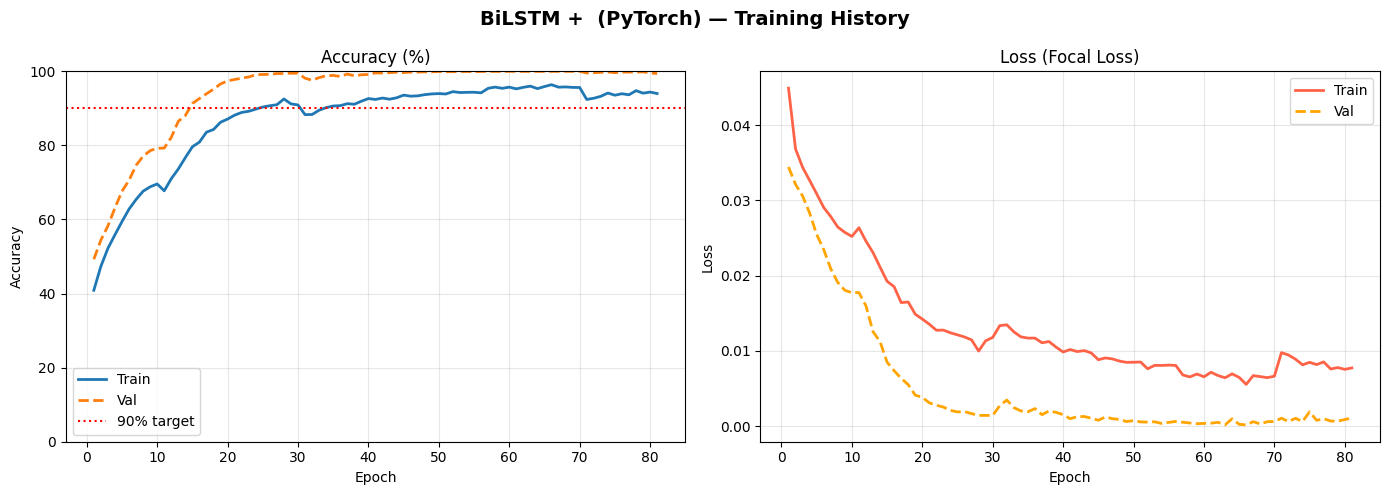

Saved -> training_history_bilstm_attn.png


In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BiLSTM +  (PyTorch) — Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, [a*100 for a in history['train_acc']],
             label='Train', linewidth=2)
axes[0].plot(epochs_ran, [a*100 for a in history['val_acc']],
             label='Val',   linewidth=2, linestyle='--')
axes[0].axhline(y=90, color='red', linestyle=':', linewidth=1.5, label='90% target')
axes[0].set_title('Accuracy (%)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])

axes[1].plot(epochs_ran, history['train_loss'],
             label='Train', linewidth=2, color='tomato')
axes[1].plot(epochs_ran, history['val_loss'],
             label='Val',   linewidth=2, linestyle='--', color='orange')
axes[1].set_title('Loss (Focal Loss)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_bilstm_attn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> training_history_bilstm_attn.png')

---
## Cell 15 — Emotion Mapping (Sample Predictions)

In [15]:
def map_to_emotion(arousal, valence):
    if   valence == 1 and arousal == 1: return 'Happy / Excited'
    elif valence == 1 and arousal == 0: return 'Content / Relaxed'
    elif valence == 0 and arousal == 1: return 'Angry / Stressed'
    else:                               return 'Sad / Bored'

n_show = min(15, len(y_true))
hdr = '{:<5} {:<13} {:<13} {:<14} {:<14} {:<20} {}'
print(hdr.format('#', 'GT Arousal', 'GT Valence',
                      'Pred Arousal', 'Pred Valence', 'Emotion', 'Match'))
print('-' * 90)

for idx in range(n_show):
    ta  = int(y_true[idx, 0])
    tv  = int(y_true[idx, 1])
    pa  = int(y_pred[idx, 0])
    pv  = int(y_pred[idx, 1])
    emo = map_to_emotion(pa, pv)
    ok  = 'OK' if (ta == pa and tv == pv) else '--'
    print(hdr.format(idx, ta, tv, pa, pv, emo, ok))

#     GT Arousal    GT Valence    Pred Arousal   Pred Valence   Emotion              Match
------------------------------------------------------------------------------------------
0     1             1             1              1              Happy / Excited      OK
1     1             1             1              1              Happy / Excited      OK
2     1             1             1              1              Happy / Excited      OK
3     1             1             1              1              Happy / Excited      OK
4     1             1             1              1              Happy / Excited      OK
5     1             1             1              1              Happy / Excited      OK
6     1             1             1              1              Happy / Excited      OK
7     1             1             1              1              Happy / Excited      OK
8     1             1             1              1              Happy / Excited      OK
9     1             1     

---
## Cell 16 — Training Log Summary

In [16]:
log_df = pd.read_csv(CSV_LOG)

best_acc_epoch  = int(log_df['val_acc'].idxmax())  + 1
best_loss_epoch = int(log_df['val_loss'].idxmin()) + 1

print('=== Training Summary ===')
print(f'Total epochs run        : {len(log_df)}')
print(f'Best val accuracy       : {log_df["val_acc"].max()*100:.2f}%  (epoch {best_acc_epoch})')
print(f'Best val loss           : {log_df["val_loss"].min():.4f}       (epoch {best_loss_epoch})')
print(f'Final train accuracy    : {log_df["train_acc"].iloc[-1]*100:.2f}%')
print(f'Model saved to          : {MODEL_PATH}')
print(f'Log saved to            : {CSV_LOG}')
print()
print('Last 5 epochs:')
print(log_df.tail(5).to_string(index=False))
print()

print('=== Final Per-Label Accuracy ===')
for i, name in enumerate(['Arousal', 'Valence']):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    status = '✓ ABOVE 90%' if acc >= 0.90 else '✗ below 90%'
    print(f'  {name}: {acc*100:.2f}%  {status}')

=== Training Summary ===
Total epochs run        : 81
Best val accuracy       : 100.00%  (epoch 68)
Best val loss           : 0.0002       (epoch 66)
Final train accuracy    : 94.01%
Model saved to          : bilstm_attn_best.pt
Log saved to            : bilstm_attn_log.csv

Last 5 epochs:
 epoch  train_loss  train_acc  val_loss  val_acc       lr
    77     0.00854    0.93663   0.00099  0.99799 0.000294
    78     0.00760    0.94784   0.00068  0.99802 0.000293
    79     0.00778    0.94108   0.00067  0.99857 0.000291
    80     0.00755    0.94393   0.00087  0.99577 0.000289
    81     0.00773    0.94009   0.00111  0.99407 0.000286

=== Final Per-Label Accuracy ===
  Arousal: 100.00%  ✓ ABOVE 90%
  Valence: 99.99%  ✓ ABOVE 90%


In [17]:
import torch

torch.save(model, "eeg_bilstm_full_model.pth")
print("Full model saved successfully")

Full model saved successfully
